# Bengaluru House Price Prediction — Simple FCNN Model


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

sns.set(style="ticks")

## 1. Load the data

In [2]:
Data = pd.read_csv('bengaluru_house_prices.csv')
Data.head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [3]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [4]:
summary = Data.describe()
print(summary)

               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000      2.000000    120.000000
max       40.000000      3.000000   3600.000000


## 2. Clean the data


In [5]:
def convert_sqft(x):
    x = str(x).strip()
    if '-' in x:
        parts = x.split('-')
        try:
            a, b = float(parts[0]), float(parts[1])
            return (a + b) / 2
        except ValueError:
            return np.nan
    try:
        return float(x)
    except ValueError:
        return np.nan
Data['total_sqft'] = Data['total_sqft'].apply(convert_sqft)

In [6]:
Data['bhk'] = Data['size'].str.extract(r'(\d+)').astype(float)

In [7]:
Data = Data.drop(columns=['society', 'availability', 'location', 'size'])
Data.head()

,area_type,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,2600.0,5.0,3.0,120.00,4.0
2,Built-up Area,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,1200.0,2.0,1.0,51.00,2.0


In [8]:
print('Missing values before cleaning:')
print(Data.isnull().sum())

Data = Data.dropna()
Data = Data.reset_index(drop=True)
print('\nShape after removing missing values:', Data.shape)

Missing values before cleaning:
area_type       0
total_sqft     46
bath           73
balcony       609
price           0
bhk            16
dtype: int64

Shape after removing missing values: (12669, 6)


In [9]:

Data = pd.get_dummies(Data, columns=['area_type'], drop_first=True, dtype=int)
Data.head()

,total_sqft,bath,balcony,price,bhk,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,1056.0,2.0,1.0,39.07,2.0,0,0,1
1,2600.0,5.0,3.0,120.00,4.0,0,1,0
2,1440.0,2.0,3.0,62.00,3.0,0,0,0
3,1521.0,3.0,1.0,95.00,3.0,0,0,1
4,1200.0,2.0,1.0,51.00,2.0,0,0,1


## 3. Explore the data (boxplot & pairplot)

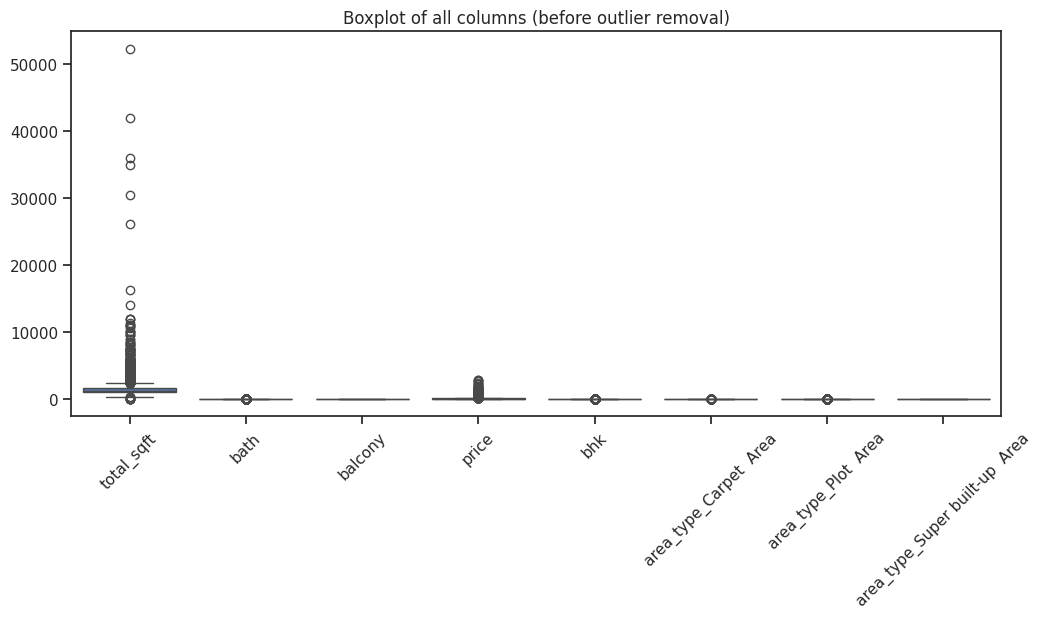

In [10]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=Data)
plt.xticks(rotation=45)
plt.title('Boxplot of all columns (before outlier removal)')
plt.show()

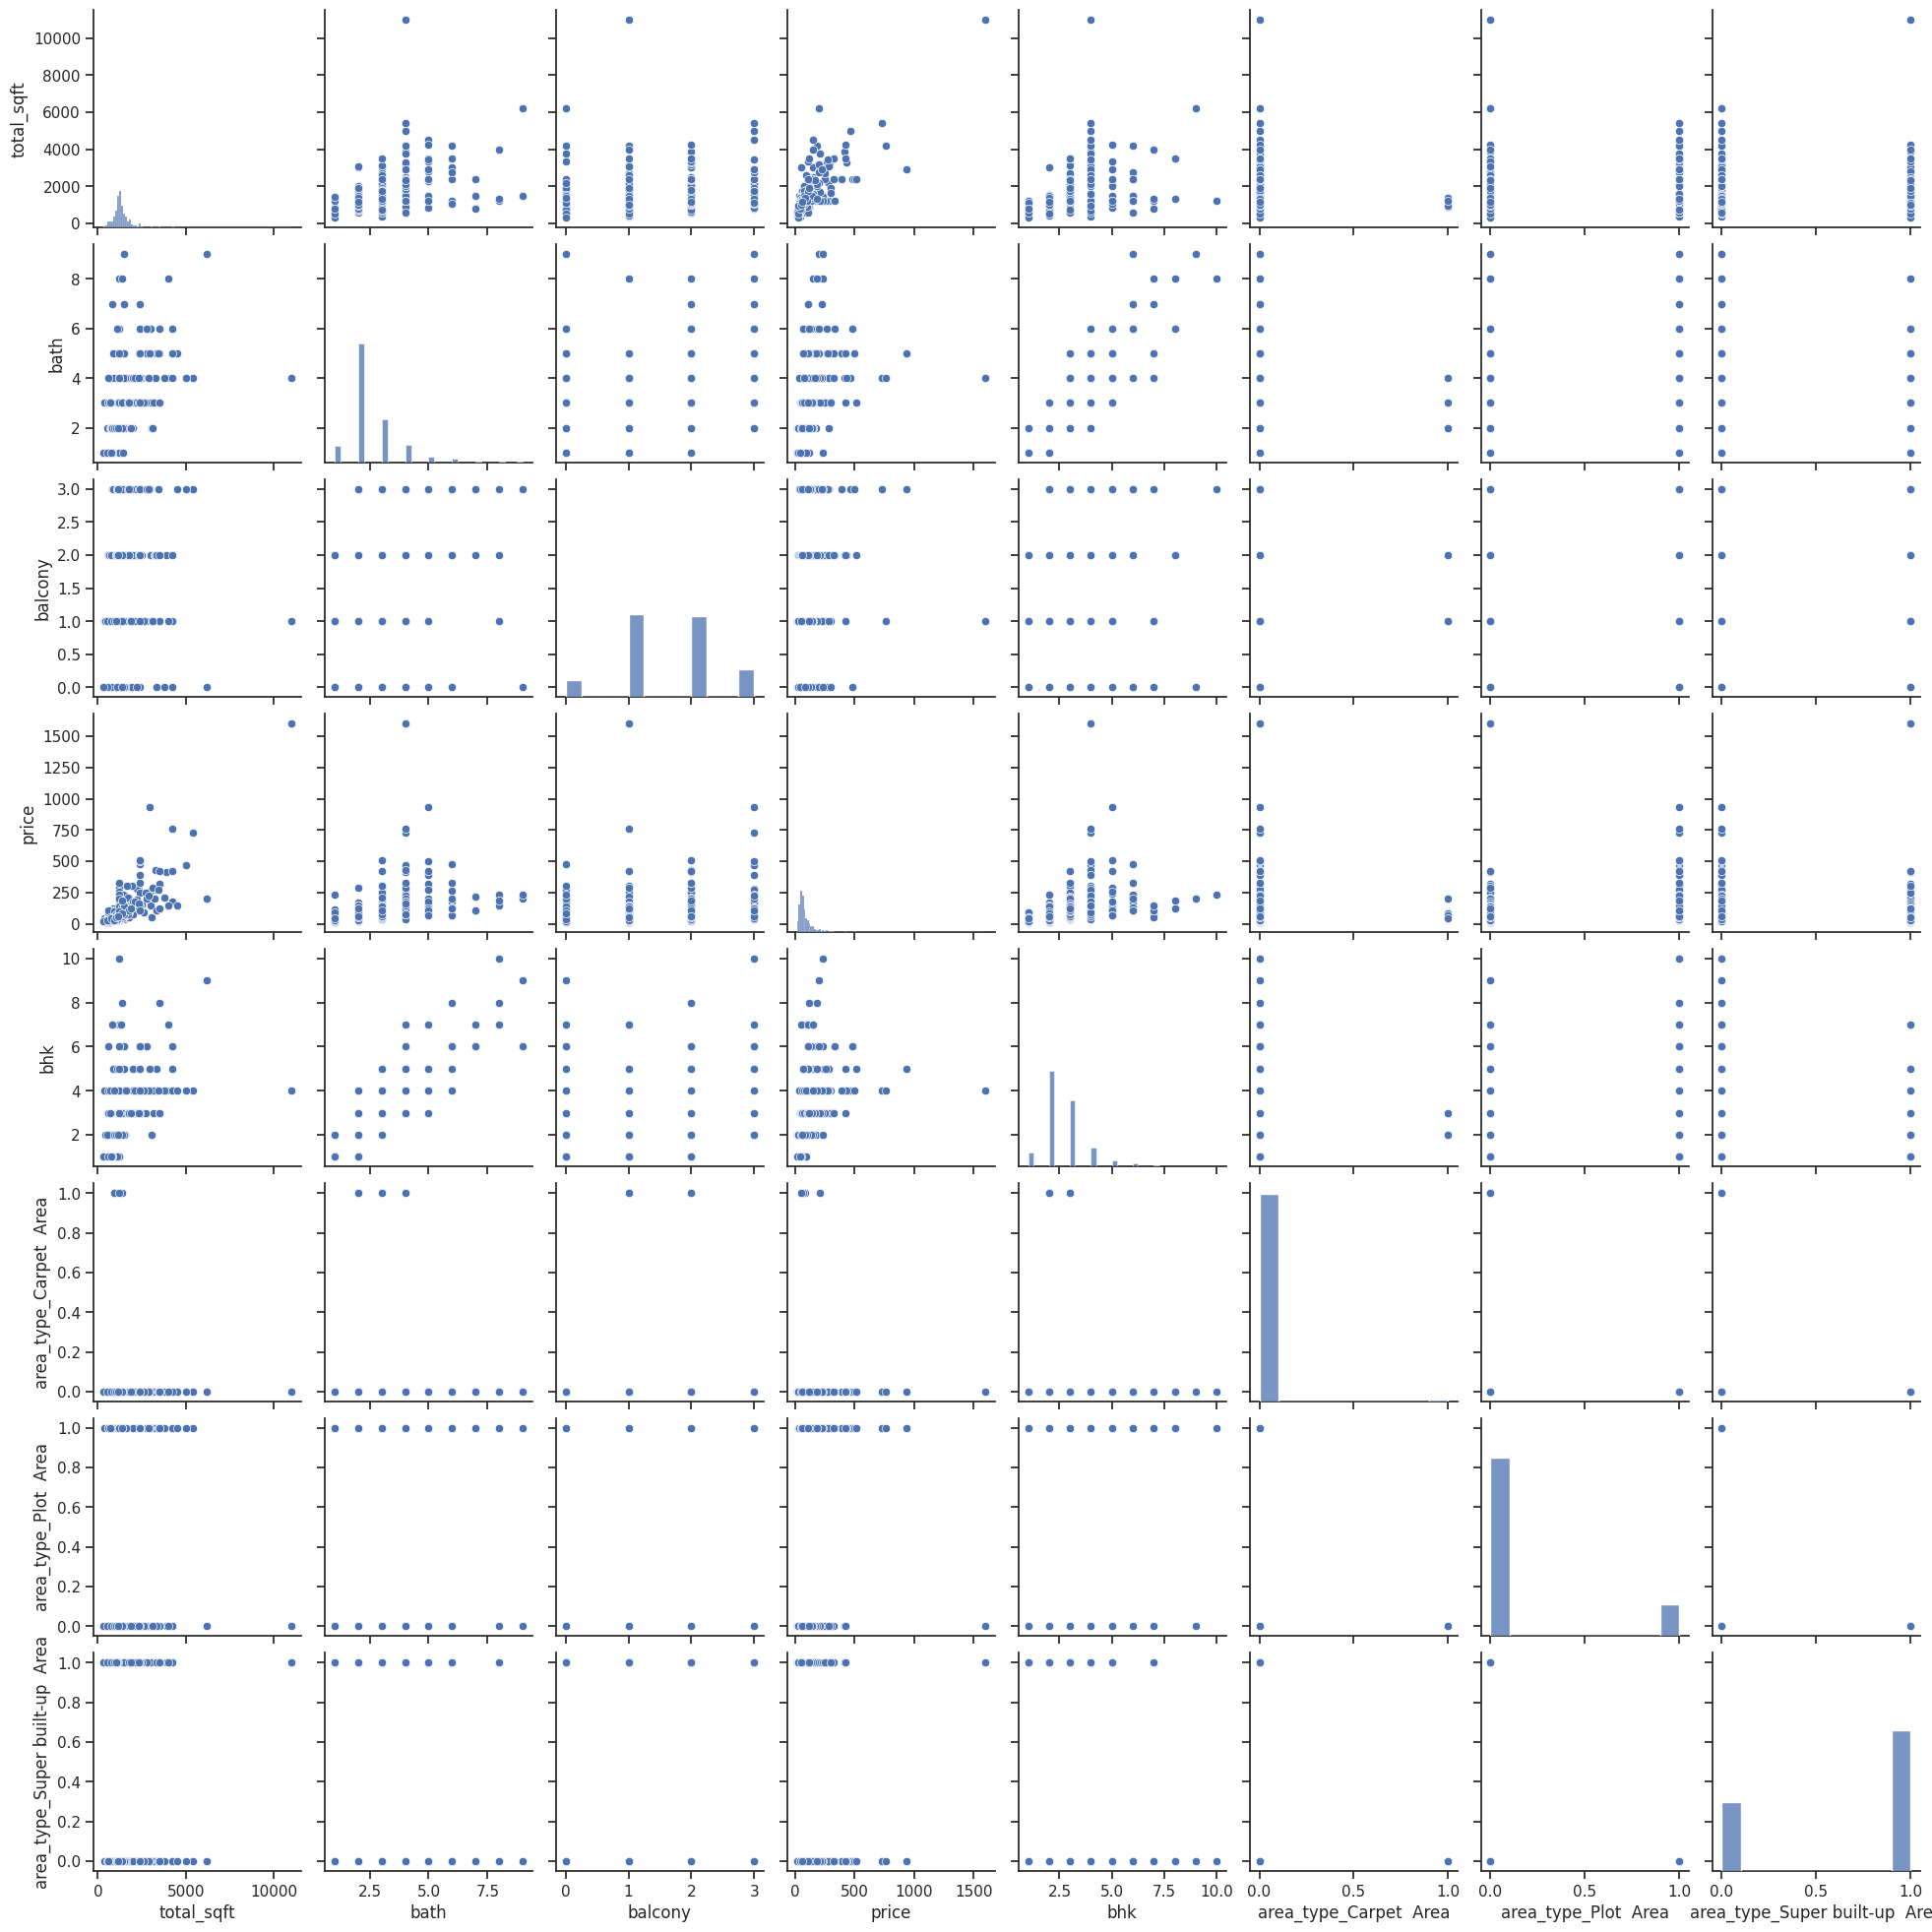

In [11]:
sns.pairplot(data=Data.sample(500, random_state=1))
plt.show()

## 4. Remove outliers (IQR method)



In [12]:
Q1 = Data.quantile(0.25)
Q3 = Data.quantile(0.75)
IQR = Q3 - Q1

DataOut = Data[~((Data < (Q1 - 1.5 * IQR)) | (Data > (Q3 + 1.5 * IQR))).any(axis=1)]
DataOut = DataOut.reset_index(drop=True)

print('Shape before removing outliers:', Data.shape)
print('Shape after removing outliers :', DataOut.shape)

Shape before removing outliers: (12669, 8)
Shape after removing outliers : (9744, 8)


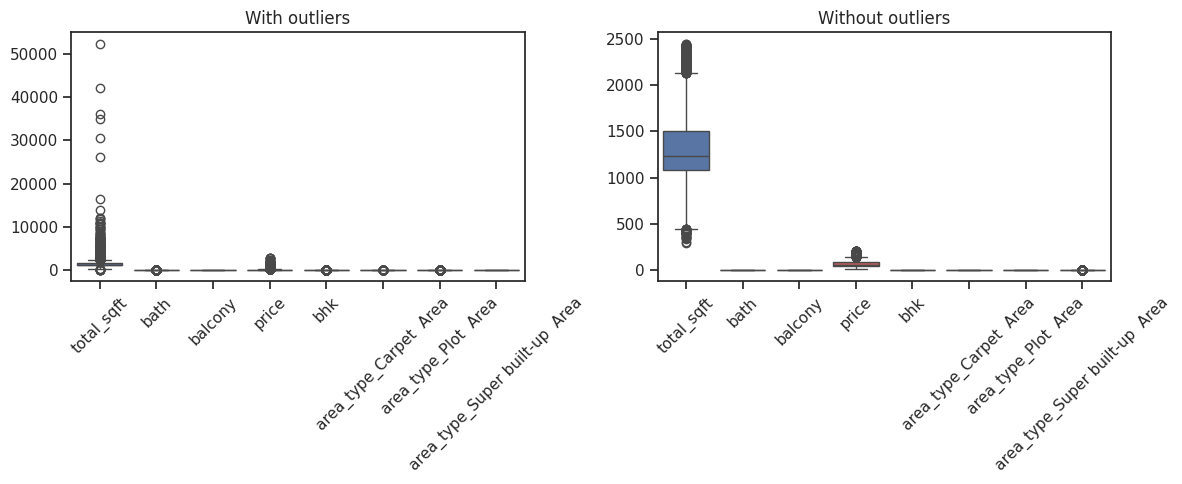

In [13]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=Data)
plt.xticks(rotation=45)
plt.title('With outliers')

plt.subplot(1, 2, 2)
sns.boxplot(data=DataOut)
plt.xticks(rotation=45)
plt.title('Without outliers')
plt.tight_layout()
plt.show()

## 5. Scale the data (MinMaxScaler)

x(scaled) = (x - x(min)) / (x(max) - x(min))

In [14]:
scaler = MinMaxScaler()
DataScaled = scaler.fit_transform(DataOut)
DataScaled = pd.DataFrame(DataScaled, columns=DataOut.columns)
DataScaled.describe()

,total_sqft,bath,balcony,price,bhk,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
count,9744.000000,9744.000000,9744.000000,9744.000000,9744.000000,9744.0,9744.0,9744.000000
mean,0.462769,0.411570,0.531985,0.302229,0.458539,0.0,0.0,0.806137
std,0.165629,0.201102,0.251180,0.172496,0.206060,0.0,0.0,0.395343
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
25%,0.363974,0.333333,0.333333,0.179104,0.333333,0.0,0.0,1.000000
50%,0.438022,0.333333,0.666667,0.253731,0.333333,0.0,0.0,1.000000
75%,0.558960,0.666667,0.666667,0.378109,0.666667,0.0,0.0,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,1.000000


## 6. Split predictors / target and train/test sets

In [15]:
target_col = 'price'
feature_cols = [c for c in DataScaled.columns if c != target_col]

Predictors = DataScaled[feature_cols]
Response = DataScaled[[target_col]]

Pred_train, Pred_test, Resp_train, Resp_test = train_test_split(
    Predictors, Response, test_size=0.2, random_state=1)

print(Pred_train.shape)
print(Pred_test.shape)
print(Resp_train.shape)
print(Resp_test.shape)

(7795, 7)
(1949, 7)
(7795, 1)
(1949, 1)


## 7. Build the FCNN model


In [16]:
def build_model(n_inputs, units=(32, 16), learning_rate=0.001):
    model = Sequential()
    model.add(Input(shape=(n_inputs,)))
    model.add(Dense(units[0], activation='relu'))
    model.add(Dense(units[1], activation='relu'))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mean_squared_error',
                  metrics=['mae'])
    return model

n_inputs = Pred_train.shape[1]
build_model(n_inputs).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Find the best hyperparameters


In [17]:
param_grid = [
    {'units': (16, 8),  'learning_rate': 0.01,   'batch_size': 32},
    {'units': (32, 16), 'learning_rate': 0.01,   'batch_size': 32},
    {'units': (32, 16), 'learning_rate': 0.001,  'batch_size': 32},
    {'units': (64, 32), 'learning_rate': 0.001,  'batch_size': 64},
    {'units': (64, 32), 'learning_rate': 0.0005, 'batch_size': 64},
]

results = []
for params in param_grid:
    model = build_model(n_inputs, units=params['units'], learning_rate=params['learning_rate'])
    history = model.fit(Pred_train, Resp_train,
                         epochs=40,
                         batch_size=params['batch_size'],
                         validation_split=0.2,
                         verbose=0)
    val_loss = history.history['val_loss'][-1]
    results.append({**params, 'val_loss': val_loss})
    print(params, '-> val_loss =', round(val_loss, 5))

results_df = pd.DataFrame(results).sort_values('val_loss').reset_index(drop=True)
results_df

{'units': (16, 8), 'learning_rate': 0.01, 'batch_size': 32} -> val_loss = 0.01134
{'units': (32, 16), 'learning_rate': 0.01, 'batch_size': 32} -> val_loss = 0.0119
{'units': (32, 16), 'learning_rate': 0.001, 'batch_size': 32} -> val_loss = 0.01154
{'units': (64, 32), 'learning_rate': 0.001, 'batch_size': 64} -> val_loss = 0.01267
{'units': (64, 32), 'learning_rate': 0.0005, 'batch_size': 64} -> val_loss = 0.01148


,units,learning_rate,batch_size,val_loss
0,"(16, 8)",0.0100,32,0.011338
1,"(64, 32)",0.0005,64,0.011479
2,"(32, 16)",0.0010,32,0.011545
3,"(32, 16)",0.0100,32,0.011905
4,"(64, 32)",0.0010,64,0.012670


In [18]:
best_params = results_df.iloc[0].to_dict()
best_units = best_params['units']
best_lr = best_params['learning_rate']
best_batch = int(best_params['batch_size'])

print('Best parameters found:')
print(best_params)

Best parameters found:
{'units': (16, 8), 'learning_rate': 0.01, 'batch_size': 32, 'val_loss': 0.011338184587657452}


## 9. Train the final model with the best parameters

In [19]:
final_model = build_model(n_inputs, units=best_units, learning_rate=best_lr)

history = final_model.fit(Pred_train, Resp_train,
                           epochs=150,
                           batch_size=best_batch,
                           validation_split=0.2,
                           verbose=1)

Epoch 1/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0265 - mae: 0.1117 - val_loss: 0.0136 - val_mae: 0.0865
Epoch 2/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0142 - mae: 0.0866 - val_loss: 0.0181 - val_mae: 0.0927
Epoch 3/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0130 - mae: 0.0817 - val_loss: 0.0136 - val_mae: 0.0885
Epoch 4/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0134 - mae: 0.0825 - val_loss: 0.0119 - val_mae: 0.0772
Epoch 5/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0131 - mae: 0.0824 - val_loss: 0.0118 - val_mae: 0.0764
Epoch 6/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0129 - mae: 0.0811 - val_loss: 0.0118 - val_mae: 0.0773
Epoch 7/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0128 - mae: 0.0812 - val_loss: 0.0130 - val_mae: 0.0859
Epoch 8/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0129 - mae: 0.0811 - val_loss: 0.0121 - val_mae: 0.0754
Epoch 9/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

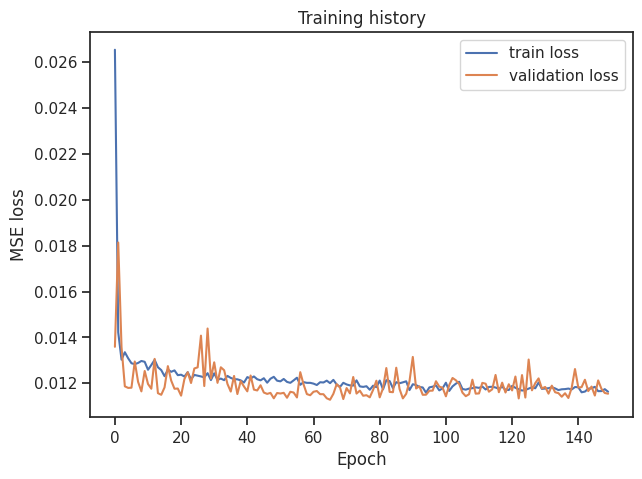

In [20]:
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Training history')
plt.legend()
plt.show()

## 10. Evaluate the model (R²)

In [21]:
y_pred = final_model.predict(Pred_test)
r2 = r2_score(Resp_test, y_pred)
mse = mean_squared_error(Resp_test, y_pred)

print('Best parameters used    :', best_params)
print('R-squared on test data  :', round(r2, 4))
print('MSE on test data        :', round(mse, 6))

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Best parameters used    : {'units': (16, 8), 'learning_rate': 0.01, 'batch_size': 32, 'val_loss': 0.011338184587657452}
R-squared on test data  : 0.62
MSE on test data        : 0.010992


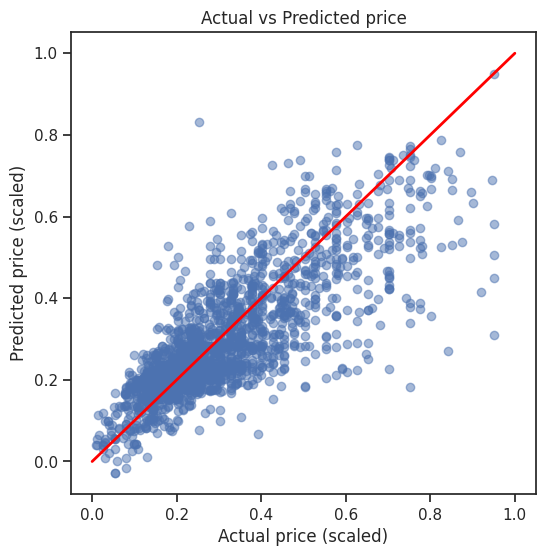

In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(Resp_test, y_pred, alpha=0.5)
plt.plot([0, 1], [0, 1], linewidth=2, color='red')
plt.xlabel('Actual price (scaled)')
plt.ylabel('Predicted price (scaled)')
plt.title('Actual vs Predicted price')
plt.show()